# Pipeline de Clasificación de Radiografías Respiratorias
## COVID-19 | Neumonía | Normal

**Proyecto Final — Análisis de Algoritmos | Aprendizaje Automático Supervisado**
Maestría en Inteligencia Artificial — UMPH

Este notebook implementa un **pipeline reproducible de inicio a fin** para clasificar radiografías
de tórax en tres clases. Se evalúan 8 algoritmos:

| # | Algoritmo | Tipo |
|---|-----------|------|
| A | CNN Propia (custom) | Deep Learning |
| B1 | KNN | Clásico |
| B2 | SVM | Clásico |
| B3 | Random Forest | Ensemble |
| B4 | Naive Bayes | Probabilístico |
| C | MLP | Red Neuronal |
| D | ResNet50 (Transfer Learning) | Deep Learning |
| E | YOLOv8-cls | Deep Learning |

**Métricas:** Accuracy · Precision · Recall · F1-Score · AUC-ROC · Support


## 0. Instalación de dependencias

In [1]:
# Instalar paquetes que pudieran faltar en el entorno
import subprocess, sys

_missing = ['scikit-image', 'imbalanced-learn']
for _pkg in _missing:
    _r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', _pkg, '-q'],
        capture_output=True, text=True
    )
    print(f"{'OK' if _r.returncode == 0 else 'ERR'} {_pkg}")


OK scikit-image
OK imbalanced-learn


## 1. Imports y configuración del entorno

In [1]:
import os, sys, random, time, warnings, shutil, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import cv2

# ── Sklearn ──────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

# ── TensorFlow / Keras ───────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── PyTorch + YOLO ───────────────────────────────────────
import torch
from ultralytics import YOLO as YOLOModel

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ── Estado del entorno ───────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow  : {tf.__version__}")
print(f"PyTorch     : {torch.__version__}")
print(f"TF GPU(s)   : {gpus if gpus else 'No GPU – usando CPU'}")
print(f"CUDA (torch): {torch.cuda.is_available()}")
print(f"Python      : {sys.version.split()[0]}")


I0000 00:00:1775666821.321234   33189 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775666821.325635   33189 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775666821.674311   33189 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775666822.994399   33189 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow  : 2.21.0
PyTorch     : 2.11.0+cu130
TF GPU(s)   : No GPU – usando CPU
CUDA (torch): False
Python      : 3.11.9


E0000 00:00:1775666826.085205   33189 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Constantes y rutas

In [2]:
# ══════════════════════════════════════════════════════════
# SEMILLA — garantiza reproducibilidad completa
# ══════════════════════════════════════════════════════════
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# ══════════════════════════════════════════════════════════
# RUTAS
# ══════════════════════════════════════════════════════════
DATASET_ROOT = Path(
    "/home/uplaph/Descargas/Enf. Respiratorias_3ro-20260327T002510Z-3-001/Enf. Respiratorias_3ro/Respiratorios/chest_xray"
)
OUTPUT_DIR = Path(
    "/home/uplaph/Documentos/UPMH/Proyecto final algoritmos"
)
MODELS_DIR  = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"
YOLO_DIR    = OUTPUT_DIR / "yolo_dataset"

for _d in [MODELS_DIR, RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Carpetas de clases (nota: trailing spaces y typo son del dataset original)
CLASS_FOLDERS = {
    'COVID'    : DATASET_ROOT / 'COVID ',     # trailing space
    'NEUMONIA' : DATASET_ROOT / 'NEUMONIA ',  # trailing space
    'NORMAL'   : DATASET_ROOT / 'NORMALL',    # typo en el dataset
}
CLASS_NAMES = list(CLASS_FOLDERS.keys())
EXTENSIONS  = {'.jpg', '.jpeg', '.png'}

# ══════════════════════════════════════════════════════════
# HIPERPARÁMETROS (ajustados post-EDA)
# ══════════════════════════════════════════════════════════
IMG_SIZE    = 224    # estándar para ResNet; razonablemente alto para radiografías
CHANNELS    = 3      # RGB – necesario para ResNet y YOLO
BATCH_SIZE  = 32
EPOCHS      = 40     # CNN propia y ResNet
FT_EPOCHS   = 20     # fine-tuning ResNet
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

print("Rutas configuradas.")
print(f"  Dataset : {DATASET_ROOT}")
print(f"  Output  : {OUTPUT_DIR}")
print(f"\nHiperparámetros:")
print(f"  IMG_SIZE={IMG_SIZE}  BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}  SEED={SEED}")
print(f"  Split   : train {1-VAL_SPLIT-TEST_SPLIT:.0%} / val {VAL_SPLIT:.0%} / test {TEST_SPLIT:.0%}")


Rutas configuradas.
  Dataset : /home/uplaph/Descargas/Enf. Respiratorias_3ro-20260327T002510Z-3-001/Enf. Respiratorias_3ro/Respiratorios/chest_xray
  Output  : /home/uplaph/Documentos/UPMH/Proyecto final algoritmos

Hiperparámetros:
  IMG_SIZE=224  BATCH=32  EPOCHS=40  SEED=42
  Split   : train 70% / val 15% / test 15%


## 3. Marco Teórico

### Problema

La clasificación automática de radiografías de tórax en **COVID-19**, **Neumonía** y **Normal**
es un problema de visión por computadora multiclase. Cada clase presenta patrones radiológicos distintos:

- **COVID-19**: opacidades bilaterales periféricas en vidrio esmerilado.
- **Neumonía**: consolidación lobar o bronconeumonía.
- **Normal**: campos pulmonares limpios sin opacidades.

### Red Neuronal Convolucional (CNN)

Una CNN aplica filtros aprendibles sobre la imagen de entrada. La operación de convolución
bidimensional se define como:

$$\text{salida}(i,j) = \sum_m\sum_n \text{imagen}(i+m,\,j+n)\cdot K(m,n)$$

donde $K$ es el kernel de tamaño $m\times n$ y $(i,j)$ es la posición de salida.
Las capas profundas detectan patrones cada vez más abstractos: bordes → texturas → opacidades.

### Transfer Learning con ResNet50

ResNet50 introduce **conexiones residuales** $F(x) + x$ que resuelven el problema de
gradiente desvaneciente, permitiendo redes de 50+ capas. Preentrenada en ImageNet (1.28 M imágenes,
1000 clases), sus representaciones de bajo nivel son transferibles al dominio médico.

### Algoritmos Clásicos

Para KNN, SVM, Random Forest y Naive Bayes se aplica **PCA** sobre los píxeles aplanados
para reducir la dimensionalidad de ~150 K a ~300 componentes (≥95% varianza explicada),
acelerando el entrenamiento sin pérdida significativa de información.

### Métricas de Evaluación

| Métrica | Fórmula | Énfasis |
|---------|---------|---------|
| Accuracy | $\frac{VP+VN}{Total}$ | Rendimiento global |
| Precision | $\frac{VP}{VP+FP}$ | Evitar falsos positivos |
| Recall | $\frac{VP}{VP+FN}$ | Evitar falsos negativos |
| F1-Score | $2\cdot\frac{P\cdot R}{P+R}$ | Balance P/R |
| AUC-ROC | Área bajo curva ROC | Poder discriminante |

En contexto médico el **Recall** (sensibilidad) es crítico: preferimos detectar todos los
enfermos aunque implique algunos falsos positivos.


## Paso 0 — Exploración inicial del dataset

In [4]:
# ══════════════════════════════════════════════════════════
# PASO 0-A: Estructura de carpetas y conteo de imágenes
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("ESTRUCTURA DEL DATASET")
print("=" * 60)

counts    = {}
all_files = {}

print("\n[Nivel raíz] Carpetas de clase usadas en el pipeline:")
for cls, folder in CLASS_FOLDERS.items():
    files = sorted([
        f for f in folder.iterdir()
        if f.suffix.lower() in EXTENSIONS and f.name != '.DS_Store'
    ])
    counts[cls]    = len(files)
    all_files[cls] = files
    print(f"  {cls:10s}: {len(files):5d} imágenes  (carpeta: {folder.name!r})")

total = sum(counts.values())
print(f"\n  TOTAL   : {total:5d} imágenes")

print("\n[Split train/test pre-existente – referencia únicamente:]")
_splits = {
    'train/Covid'    : DATASET_ROOT / 'train' / 'Covid',
    'train/NORMAL'   : DATASET_ROOT / 'train' / 'NORMAL',
    'train/PNEUMONIA': DATASET_ROOT / 'train' / 'PNEUMONIA',
    'test/Covid'     : DATASET_ROOT / 'test'  / 'Covid',
    'test/NORMAL'    : DATASET_ROOT / 'test'  / 'NORMAL',
    'test/PNEUMONIA' : DATASET_ROOT / 'test'  / 'PNEUMONIA',
}
for name, folder in _splits.items():
    n = len([f for f in folder.iterdir()
             if f.suffix.lower() in EXTENSIONS]) if folder.exists() else 0
    status = '' if n > 0 else '  ← vacío'
    print(f"  {name:25s}: {n:5d}{status}")

print("\n→ Se usan las carpetas raíz. Split manual estratificado 70/15/15.")


ESTRUCTURA DEL DATASET

[Nivel raíz] Carpetas de clase usadas en el pipeline:
  COVID     :   138 imágenes  (carpeta: 'COVID ')
  NEUMONIA  :  1604 imágenes  (carpeta: 'NEUMONIA ')
  NORMAL    :  1399 imágenes  (carpeta: 'NORMALL')

  TOTAL   :  3141 imágenes

[Split train/test pre-existente – referencia únicamente:]
  train/Covid              :    41
  train/NORMAL             :   184
  train/PNEUMONIA          :  2669
  test/Covid               :    26
  test/NORMAL              :     0  ← vacío
  test/PNEUMONIA           :     0  ← vacío

→ Se usan las carpetas raíz. Split manual estratificado 70/15/15.


In [5]:
# ══════════════════════════════════════════════════════════
# PASO 0-B: Distribución de clases y desbalance
# ══════════════════════════════════════════════════════════
print("DISTRIBUCIÓN DE CLASES:")
for cls, n in counts.items():
    bar  = '█' * int(n / 40)
    pct  = n / total * 100
    print(f"  {cls:10s}: {n:5d}  {bar:<40s}  {pct:.1f}%")

_max = max(counts.values())
_min = min(counts.values())
_ratio = _max / _min
print(f"\nRatio de desbalance (máx/mín): {_ratio:.1f}x")

if _ratio > 3:
    print("→ Desbalance significativo detectado.")
    print("  Estrategia: class_weight='balanced' en TF/Keras y sklearn.")
else:
    print("→ Dataset relativamente balanceado.")

# Calcular class_weights
_labels_all = []
for i, cls in enumerate(CLASS_NAMES):
    _labels_all.extend([i] * counts[cls])
_labels_all  = np.array(_labels_all)
_cw_vals     = compute_class_weight('balanced',
                                     classes=np.unique(_labels_all),
                                     y=_labels_all)
CLASS_WEIGHTS = dict(enumerate(_cw_vals))
print(f"\nClass weights (TF/Keras):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i} ({cls:10s}): {CLASS_WEIGHTS[i]:.4f}")


DISTRIBUCIÓN DE CLASES:
  COVID     :   138  ███                                       4.4%
  NEUMONIA  :  1604  ████████████████████████████████████████  51.1%
  NORMAL    :  1399  ██████████████████████████████████        44.5%

Ratio de desbalance (máx/mín): 11.6x
→ Desbalance significativo detectado.
  Estrategia: class_weight='balanced' en TF/Keras y sklearn.

Class weights (TF/Keras):
  0 (COVID     ): 7.5870
  1 (NEUMONIA  ): 0.6527
  2 (NORMAL    ): 0.7484


In [6]:
# ══════════════════════════════════════════════════════════
# PASO 0-C: Dimensiones y modos (muestra de 5 por clase)
# ══════════════════════════════════════════════════════════
print("DIMENSIONES Y MODOS DE LAS IMÁGENES:")
print("-" * 60)

_widths, _heights = [], []

for cls, files in all_files.items():
    sample = random.sample(files, min(5, len(files)))
    print(f"\n  {cls}:")
    for f in sample:
        try:
            img = Image.open(f)
            w, h = img.size
            _widths.append(w)
            _heights.append(h)
            exts = f.suffix.lower()
            print(f"    {f.name[:42]:42s}  {w:4d}x{h:4d}  {img.mode}")
        except Exception as e:
            print(f"    ERROR: {f.name}: {e}")

print(f"\nResumen ({len(_widths)} imágenes muestreadas):")
print(f"  Ancho  : min={min(_widths):4d}  max={max(_widths):4d}  media={np.mean(_widths):.0f}")
print(f"  Alto   : min={min(_heights):4d}  max={max(_heights):4d}  media={np.mean(_heights):.0f}")
print(f"\n→ Redimensionar a {IMG_SIZE}×{IMG_SIZE} px")
print("→ Convertir a RGB (3 canales) para compatibilidad uniforme")


DIMENSIONES Y MODOS DE LAS IMÁGENES:
------------------------------------------------------------

  COVID:
    092.png                                      439x 391  RGBA
    065.jpeg                                    1696x1403  RGB
    Copia de 01.jpeg                            4248x3480  RGB
    COVID-00031.jpg                              892x 734  L
    COVID-00026.jpg                              895x 732  L

  NEUMONIA:
    person1310_bacteria_3300.jpeg               1392x 832  L
    person78_bacteria_385.jpeg                   936x 568  L
    person1280_bacteria_3243.jpeg               1368x1044  L
    person53_bacteria_252.jpeg                  1292x 936  L
    person7_bacteria_29.jpeg                    1200x 824  L

  NORMAL:
    NORMAL2-IM-0821-0001.jpeg                   1836x1487  L
    IM-0285-0001.jpeg                           1426x1101  L
    NORMAL2-IM-0926-0001.jpeg                   1586x1217  L
    NORMAL2-IM-0417-0001.jpeg                   2302x1514  L
    IM-

## 4. Análisis Exploratorio de Datos (EDA)

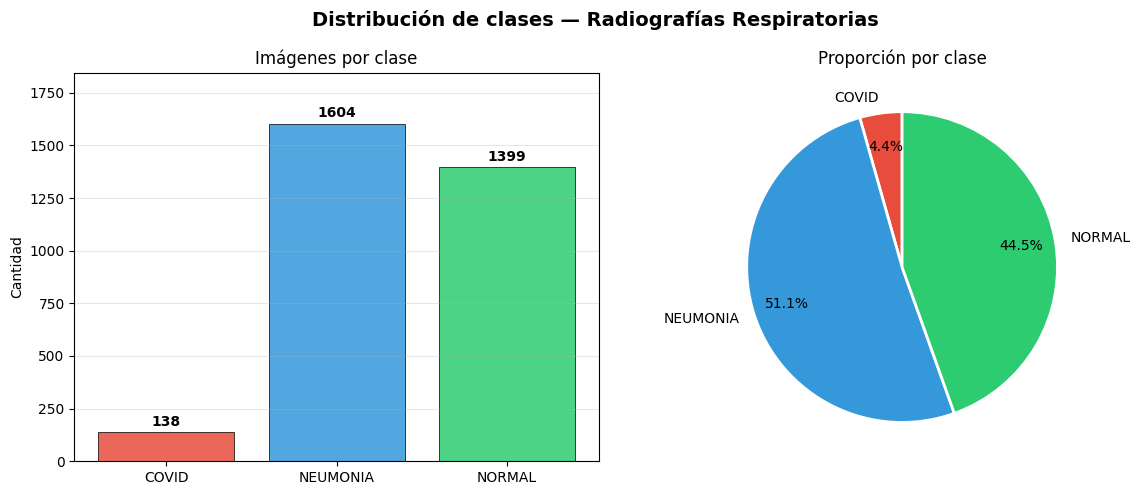

In [9]:
# EDA-1: Distribución de clases
_colors = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de clases — Radiografías Respiratorias',
             fontsize=14, fontweight='bold')

# Barras
_vals = [counts[c] for c in CLASS_NAMES]
bars = axes[0].bar(CLASS_NAMES, _vals, color=_colors,
                   edgecolor='black', linewidth=0.6, alpha=0.85)
for bar, n in zip(bars, _vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 str(n), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Imágenes por clase', fontsize=12)
axes[0].set_ylabel('Cantidad')
axes[0].set_ylim(0, max(_vals) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Pie
axes[1].pie(_vals, labels=CLASS_NAMES, colors=_colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.78,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporción por clase', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_01_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()


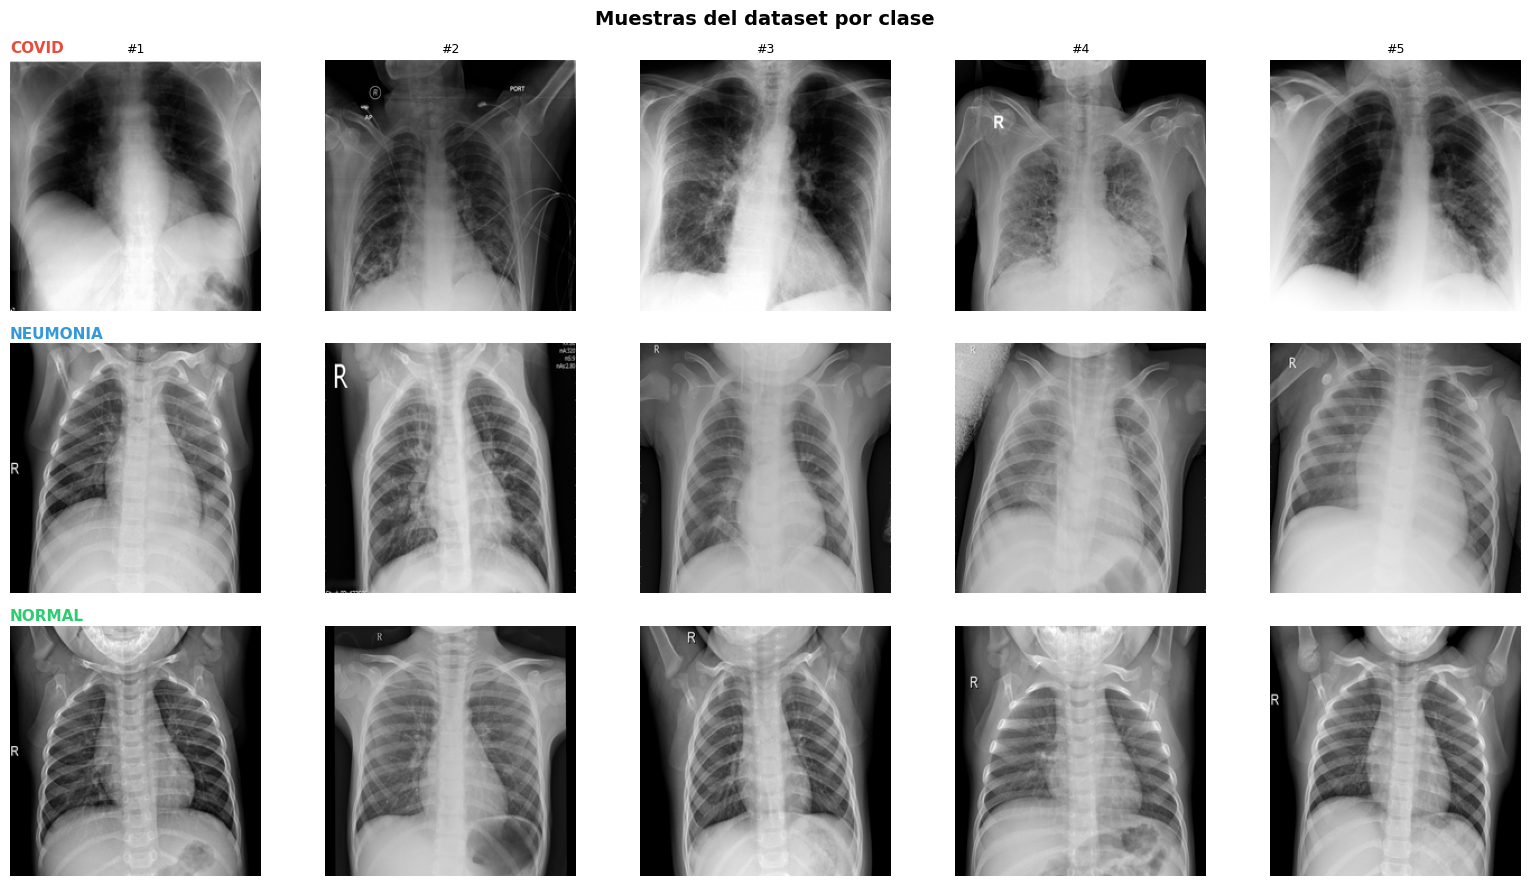

In [10]:
# EDA-2: Grid de imágenes de muestra (5 por clase)
n_sample = 5
fig, axes = plt.subplots(3, n_sample, figsize=(16, 9))
fig.suptitle('Muestras del dataset por clase', fontsize=14, fontweight='bold')

for row, (cls, files) in enumerate(all_files.items()):
    sample = random.sample(files, n_sample)
    for col, f in enumerate(sample):
        img = Image.open(f).convert('RGB').resize((224, 224), Image.LANCZOS)
        axes[row, col].imshow(np.array(img))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, fontweight='bold',
                                      loc='left', pad=4, color=_colors[row])
        if row == 0:
            axes[row, col].set_title(f'#{col+1}', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_02_muestras.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# EDA-3: Histogramas de intensidad (escala de grises)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Distribución de intensidades de píxeles (escala de grises)',
             fontsize=13, fontweight='bold')

for ax, (cls, files), col in zip(axes, all_files.items(), _colors):
    sample = random.sample(files, min(30, len(files)))
    pixels = []
    for f in sample:
        arr = np.array(Image.open(f).convert('L'))
        pixels.extend(arr.flatten().tolist())
    mean_v = np.mean(pixels)
    std_v  = np.std(pixels)
    ax.hist(pixels, bins=64, color=col, alpha=0.7, edgecolor='none', density=True)
    ax.axvline(mean_v, color='black', linestyle='--', lw=1.8,
               label=f'μ={mean_v:.0f}  σ={std_v:.0f}')
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.set_xlabel('Intensidad (0–255)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_03_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Preprocesamiento

Se cargan todas las imágenes, se convierten a **RGB**, se redimensionan a **224×224 px**
y se normalizan al rango **[0, 1]**. Luego se realiza un **split estratificado 70/15/15**.

Para CNN y ResNet el data augmentation se aplica **solo en train** (no filtra hacia val/test).


In [11]:
# ══════════════════════════════════════════════════════════
# Carga de imágenes en memoria
# ══════════════════════════════════════════════════════════
# Nota: ~3142 imágenes × 224×224×3 × float32 ≈ 1.2 GB en RAM
print("Cargando imágenes... (puede tardar 1-3 min dependiendo del hardware)")
_t0 = time.time()

X_all, y_all, path_all = [], [], []
_load_errors = 0

for _lbl, (cls, files) in enumerate(all_files.items()):
    print(f"  Cargando {cls} ({len(files)} imgs)...", end=' ', flush=True)
    _ok = 0
    for f in files:
        try:
            img = Image.open(f).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            X_all.append(np.array(img, dtype=np.float32) / 255.0)
            y_all.append(_lbl)
            path_all.append(f)
            _ok += 1
        except Exception as e:
            _load_errors += 1
    print(f"{_ok} OK")

X_all    = np.array(X_all, dtype=np.float32)
y_all    = np.array(y_all, dtype=np.int32)
path_all = np.array(path_all)

print(f"\nX shape : {X_all.shape}  dtype={X_all.dtype}")
print(f"y shape : {y_all.shape}  clases: {np.unique(y_all)}")
print(f"Errores : {_load_errors}")
print(f"Tiempo  : {time.time()-_t0:.1f}s")


Cargando imágenes... (puede tardar 1-3 min dependiendo del hardware)
  Cargando COVID (138 imgs)... 138 OK
  Cargando NEUMONIA (1604 imgs)... 1604 OK
  Cargando NORMAL (1399 imgs)... 1399 OK

X shape : (3141, 224, 224, 3)  dtype=float32
y shape : (3141,)  clases: [0 1 2]
Errores : 0
Tiempo  : 58.4s


In [12]:
# ══════════════════════════════════════════════════════════
# Split estratificado 70 / 15 / 15
# ══════════════════════════════════════════════════════════
_val_frac = VAL_SPLIT / (1.0 - TEST_SPLIT)  # = 15/85 ≈ 0.176

X_trainval, X_test, y_trainval, y_test, path_trainval, path_test = train_test_split(
    X_all, y_all, path_all,
    test_size=TEST_SPLIT, stratify=y_all, random_state=SEED
)
X_train, X_val, y_train, y_val, path_train, path_val = train_test_split(
    X_trainval, y_trainval, path_trainval,
    test_size=_val_frac, stratify=y_trainval, random_state=SEED
)

print("Split estratificado finalizado:")
print(f"{'Split':6s}  {'Total':>6s}  " + "  ".join(f"{c:>10s}" for c in CLASS_NAMES))
print("-" * 50)
for name, y in [('TRAIN', y_train), ('VAL', y_val), ('TEST', y_test)]:
    dist = [np.sum(y == i) for i in range(len(CLASS_NAMES))]
    row  = "  ".join(f"{d:>10d}" for d in dist)
    print(f"{name:6s}  {len(y):>6d}  {row}")

print(f"\nTotal: {len(y_all)}")


Split estratificado finalizado:
Split    Total       COVID    NEUMONIA      NORMAL
--------------------------------------------------
TRAIN     2197          96        1122         979
VAL        472          21         241         210
TEST       472          21         241         210

Total: 3141


In [13]:
# ══════════════════════════════════════════════════════════
# Helper de métricas — usado por TODOS los modelos
# ══════════════════════════════════════════════════════════
all_results = {}  # dict global: {model_name: {metric: value}}

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    if y_prob is not None:
        y_bin     = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
        auc_score = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    else:
        auc_score = float('nan')

    result = dict(Accuracy=acc, Precision=prec, Recall=rec,
                  F1_Score=f1, AUC_ROC=auc_score)
    all_results[model_name] = result

    sep = '=' * 55
    print(f"\n{sep}")
    print(f"  {model_name}")
    print(sep)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    for k, v in result.items():
        print(f"  {k:<12s}: {v:.4f}")
    return result


def plot_confusion_matrix(model_name, y_true, y_pred):
    cm_arr = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='#ccc', ax=ax)
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Etiqueta real', fontsize=11)
    ax.set_title(f'Matriz de Confusión — {model_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    _fn = f'cm_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(RESULTS_DIR / _fn, dpi=150, bbox_inches='tight')
    plt.show()


def plot_roc_curves(model_name, y_true, y_prob):
    y_bin = label_binarize(y_true, classes=list(range(len(CLASS_NAMES))))
    fig, ax = plt.subplots(figsize=(6, 5))
    _roc_colors = ['#E74C3C', '#3498DB', '#2ECC71']
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, _roc_colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        _auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={_auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('Tasa de Falsos Positivos'); ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title(f'Curvas ROC — {model_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    _fn = f'roc_{model_name.replace(" ", "_").lower()}.png'
    plt.savefig(RESULTS_DIR / _fn, dpi=150, bbox_inches='tight')
    plt.show()


print("Helpers definidos: compute_metrics · plot_confusion_matrix · plot_roc_curves")


Helpers definidos: compute_metrics · plot_confusion_matrix · plot_roc_curves


---
## Bloque A — CNN Propia (núcleo del artículo científico)

Arquitectura custom de 3 bloques convolucionales:

```
Entrada 224×224×3
  └─ [Conv2D(32)×2 → BN → MaxPool → Dropout(0.25)]   Bloque 1: features básicas
  └─ [Conv2D(64)×2 → BN → MaxPool → Dropout(0.30)]   Bloque 2: patrones intermedios
  └─ [Conv2D(128)×2 → BN → MaxPool → Dropout(0.35)]  Bloque 3: features de alto nivel
  └─ GlobalAveragePooling2D
  └─ Dense(256, ReLU) → Dropout(0.50)
  └─ Dense(3, Softmax)
```

**Justificación de decisiones:**
- Filtros crecientes (32→64→128): mayor capacidad de abstracción en capas profundas.
- BatchNorm: estabiliza el entrenamiento y actúa como regularizador implícito.
- GAP en vez de Flatten: reduce parámetros y el riesgo de sobreajuste.
- Dropout progresivo (0.25→0.35→0.50): más agresivo en las capas densas.
- L2 regularización (λ=1e-4) en todos los Conv2D y Dense.


In [15]:
# ══════════════════════════════════════════════════════════
# Definición de la arquitectura CNN
# ══════════════════════════════════════════════════════════
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS),
              num_classes=len(CLASS_NAMES)):

    inputs = tf.keras.Input(shape=input_shape, name='input_img')

    # ── Bloque 1: features básicas (bordes, texturas) ──────
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Bloque 2: patrones intermedios ─────────────────────
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.30)(x)

    # ── Bloque 3: features de alto nivel (opacidades) ──────
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.35)(x)

    # ── Clasificador ───────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs, outputs, name='CNN_Radiografias')


cnn_model = build_cnn()
cnn_model.summary()
print(f"\nParámetros totales     : {cnn_model.count_params():,}")
print(f"Parámetros entrenables : {sum(np.prod(v.shape) for v in cnn_model.trainable_variables):,}")


Model: "CNN_Radiografias"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 322,595 (1.23 MB)

 Trainable params: 321,699 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Parámetros totales     : 322,595
Parámetros entrenables : 321,699


In [16]:
# ══════════════════════════════════════════════════════════
# Entrenamiento CNN
# ══════════════════════════════════════════════════════════
_cnn_path  = MODELS_DIR / 'cnn_radiografias.keras'
_hist_path = MODELS_DIR / 'cnn_history.pkl'
cnn_history = None

_t_start = time.time()
print(f"[CNN] Inicio: {time.strftime('%H:%M:%S')}")

if _cnn_path.exists():
    print("→ Cargando modelo guardado...")
    cnn_model = tf.keras.models.load_model(_cnn_path)
    if _hist_path.exists():
        cnn_history = pickle.load(open(_hist_path, 'rb'))
else:
    # Data augmentation – solo sobre el conjunto de entrenamiento
    _datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.10,
        height_shift_range=0.10,
        zoom_range=0.10,
        horizontal_flip=True,
        brightness_range=[0.85, 1.15],
    )
    _train_gen = _datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
    _val_gen   = ImageDataGenerator().flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

    cnn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    _callbacks = [
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=4, min_lr=1e-6, verbose=1),
        ModelCheckpoint(str(_cnn_path), monitor='val_accuracy',
                        save_best_only=True, verbose=0),
    ]

    _hist = cnn_model.fit(
        _train_gen,
        epochs=EPOCHS,
        validation_data=_val_gen,
        class_weight=CLASS_WEIGHTS,
        callbacks=_callbacks,
        verbose=1,
    )
    cnn_history = _hist.history
    pickle.dump(cnn_history, open(_hist_path, 'wb'))
    print("Modelo guardado.")

print(f"[CNN] Tiempo total: {time.time()-_t_start:.1f}s")


[CNN] Inicio: 10:52:22
Epoch 1/40


I0000 00:00:1775667143.249639   33189 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


69/69 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.3286 - loss: 1.1673 - val_accuracy: 0.0445 - val_loss: 1.4792 - learning_rate: 0.0010
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.3564 - loss: 1.1423 - val_accuracy: 0.0445 - val_loss: 2.5522 - learning_rate: 0.0010
Epoch 3/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.3969 - loss: 1.1310 - val_accuracy: 0.0445 - val_loss: 5.0270 - learning_rate: 0.0010
Epoch 4/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.3254 - loss: 1.1340 - val_accuracy: 0.0445 - val_loss: 5.6928 - learning_rate: 0.0010
Epoch 5/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3359 - loss: 1.1801
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
69/69 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.3896 - loss: 1.1403 - val_accuracy: 0.0445 - val_loss: 37.7176 - learning_rate: 0.0010
Epoch 6/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.4192 - loss: 1.1329 - val_accuracy: 0.0445

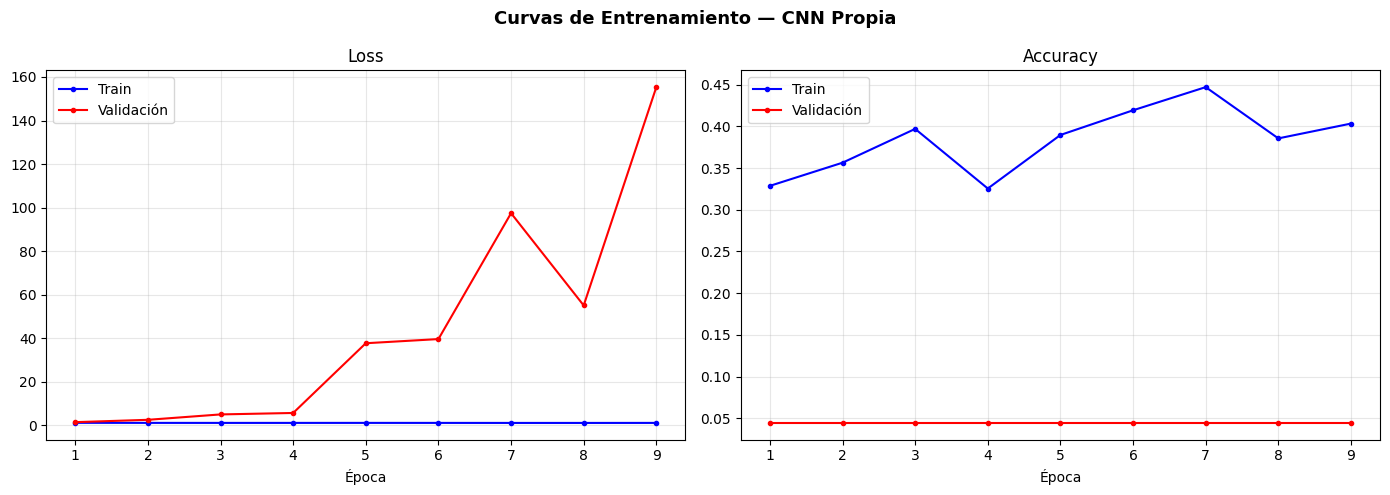

In [17]:
# ══════════════════════════════════════════════════════════
# Curvas de entrenamiento CNN
# ══════════════════════════════════════════════════════════
if cnn_history:
    _ep = range(1, len(cnn_history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Curvas de Entrenamiento — CNN Propia', fontsize=13, fontweight='bold')

    axes[0].plot(_ep, cnn_history['loss'],     'b-o', ms=3, label='Train')
    axes[0].plot(_ep, cnn_history['val_loss'], 'r-o', ms=3, label='Validación')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Época')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(_ep, cnn_history['accuracy'],     'b-o', ms=3, label='Train')
    axes[1].plot(_ep, cnn_history['val_accuracy'], 'r-o', ms=3, label='Validación')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Época')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'cnn_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()



  CNN Propia
              precision    recall  f1-score   support

       COVID       0.04      1.00      0.09        21
    NEUMONIA       0.00      0.00      0.00       241
      NORMAL       0.00      0.00      0.00       210

    accuracy                           0.04       472
   macro avg       0.01      0.33      0.03       472
weighted avg       0.00      0.04      0.00       472

  Accuracy    : 0.0445
  Precision   : 0.0020
  Recall      : 0.0445
  F1_Score    : 0.0038
  AUC_ROC     : 0.4911


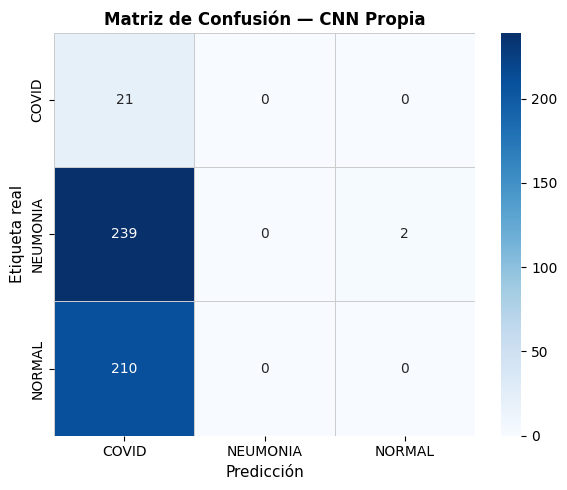

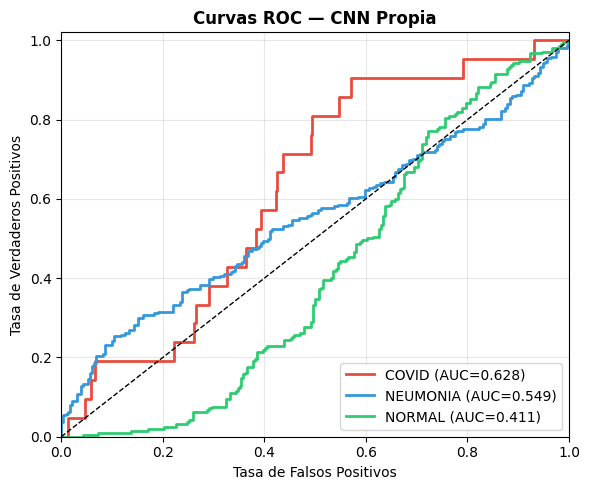

In [18]:
# ══════════════════════════════════════════════════════════
# Evaluación CNN
# ══════════════════════════════════════════════════════════
y_prob_cnn = cnn_model.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

compute_metrics('CNN Propia', y_test, y_pred_cnn, y_prob_cnn)
plot_confusion_matrix('CNN Propia', y_test, y_pred_cnn)
plot_roc_curves('CNN Propia', y_test, y_prob_cnn)


---
## Bloque B — Algoritmos Clásicos (KNN · SVM · Random Forest · Naive Bayes)

Se aplica **PCA** sobre los píxeles aplanados (224×224×3 = 150,528 dims → ≤300 componentes)
para acelerar KNN y SVM sin pérdida relevante de información.


In [19]:
# ══════════════════════════════════════════════════════════
# Extracción de features con PCA
# ══════════════════════════════════════════════════════════
_pca_path = MODELS_DIR / 'pca.pkl'
_t0 = time.time()
print("Aplanando imágenes...")

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)
X_test_flat  = X_test.reshape(len(X_test),  -1)
print(f"Dimensiones brutas: {X_train_flat.shape[1]:,}")

_n_comp = min(300, X_train_flat.shape[0] - 1)

if _pca_path.exists():
    print("→ Cargando PCA guardado...")
    pca = joblib.load(_pca_path)
else:
    print(f"Ajustando PCA ({_n_comp} componentes)...")
    pca = PCA(n_components=_n_comp, random_state=SEED)
    pca.fit(X_train_flat)
    joblib.dump(pca, _pca_path)

X_train_pca = pca.transform(X_train_flat)
X_val_pca   = pca.transform(X_val_flat)
X_test_pca  = pca.transform(X_test_flat)

_var = np.cumsum(pca.explained_variance_ratio_)[-1]
print(f"PCA {_n_comp} componentes → {_var*100:.1f}% varianza explicada")
print(f"Tiempo: {time.time()-_t0:.1f}s")


Aplanando imágenes...
Dimensiones brutas: 150,528
Ajustando PCA (300 componentes)...
PCA 300 componentes → 93.4% varianza explicada
Tiempo: 21.6s


[KNN] Inicio: 11:14:48
Buscando k óptimo (CV=5)...
  k= 3: F1=0.8904 ± 0.0164
  k= 5: F1=0.8966 ± 0.0177
  k= 7: F1=0.8967 ± 0.0176
  k= 9: F1=0.8916 ± 0.0179
  k=11: F1=0.8928 ± 0.0187
  k=15: F1=0.8950 ± 0.0162

  Mejor k=7  (F1=0.8967)
[KNN] Tiempo: 1.8s

  KNN
              precision    recall  f1-score   support

       COVID       1.00      0.95      0.98        21
    NEUMONIA       0.93      0.94      0.93       241
      NORMAL       0.92      0.92      0.92       210

    accuracy                           0.93       472
   macro avg       0.95      0.94      0.94       472
weighted avg       0.93      0.93      0.93       472

  Accuracy    : 0.9301
  Precision   : 0.9302
  Recall      : 0.9301
  F1_Score    : 0.9301
  AUC_ROC     : 0.9796


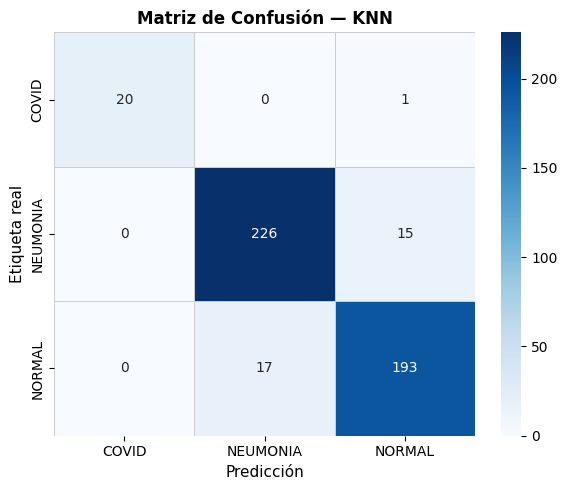

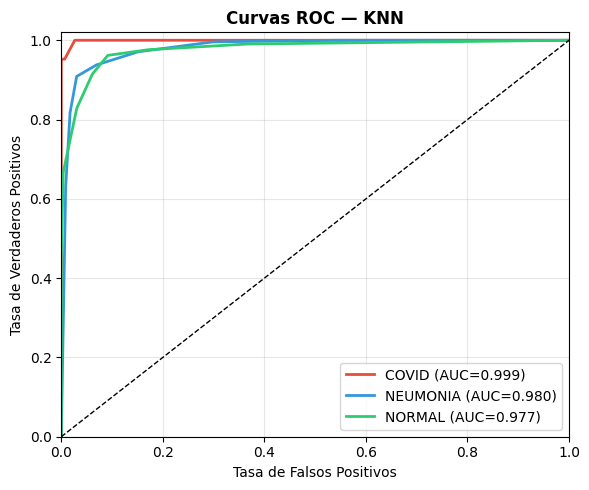

In [20]:
# ══════════════════════════════════════════════════════════
# KNN – búsqueda de k óptimo via cross-validation
# ══════════════════════════════════════════════════════════
_knn_path = MODELS_DIR / 'knn.pkl'
_t_start  = time.time()
print(f"[KNN] Inicio: {time.strftime('%H:%M:%S')}")

if _knn_path.exists():
    knn_model = joblib.load(_knn_path)
    print("→ Modelo cargado.")
else:
    _k_vals = [3, 5, 7, 9, 11, 15]
    _cv_scores = []
    print("Buscando k óptimo (CV=5)...")
    for k in _k_vals:
        _sc = cross_val_score(
            KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1),
            X_train_pca, y_train, cv=5, scoring='f1_weighted'
        )
        _cv_scores.append(_sc.mean())
        print(f"  k={k:2d}: F1={_sc.mean():.4f} ± {_sc.std():.4f}")

    _best_k = _k_vals[int(np.argmax(_cv_scores))]
    print(f"\n  Mejor k={_best_k}  (F1={max(_cv_scores):.4f})")
    knn_model = KNeighborsClassifier(n_neighbors=_best_k, metric='euclidean', n_jobs=-1)
    knn_model.fit(X_train_pca, y_train)
    joblib.dump(knn_model, _knn_path)

print(f"[KNN] Tiempo: {time.time()-_t_start:.1f}s")

y_pred_knn = knn_model.predict(X_test_pca)
y_prob_knn = knn_model.predict_proba(X_test_pca)
compute_metrics('KNN', y_test, y_pred_knn, y_prob_knn)
plot_confusion_matrix('KNN', y_test, y_pred_knn)
plot_roc_curves('KNN', y_test, y_prob_knn)


[SVM] Inicio: 11:15:03
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  Mejores parámetros: {'C': 10, 'gamma': 'scale'}
  CV F1: 0.9311
[SVM] Tiempo: 13.6s

  SVM
              precision    recall  f1-score   support

       COVID       1.00      1.00      1.00        21
    NEUMONIA       0.97      0.95      0.96       241
      NORMAL       0.95      0.97      0.96       210

    accuracy                           0.96       472
   macro avg       0.97      0.98      0.97       472
weighted avg       0.96      0.96      0.96       472

  Accuracy    : 0.9640
  Precision   : 0.9643
  Recall      : 0.9640
  F1_Score    : 0.9640
  AUC_ROC     : 0.9955


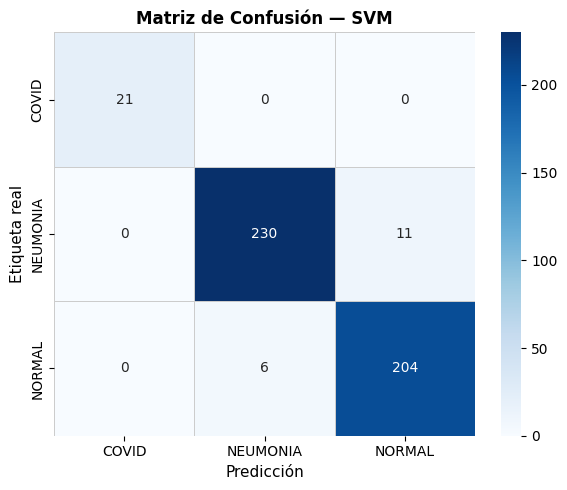

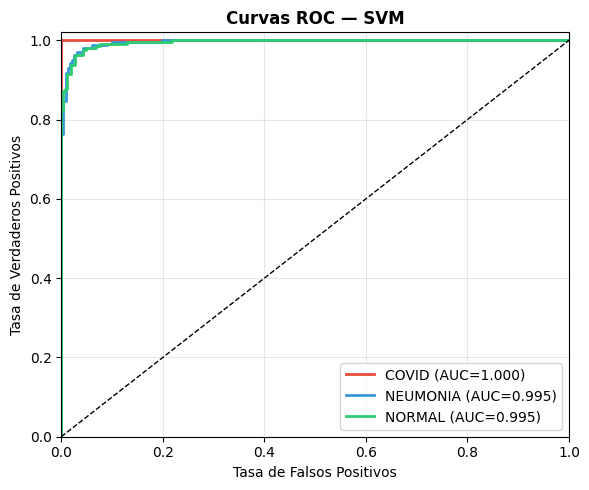

In [21]:
# ══════════════════════════════════════════════════════════
# SVM – kernel RBF con GridSearchCV
# ══════════════════════════════════════════════════════════
_svm_path = MODELS_DIR / 'svm.pkl'
_t_start  = time.time()
print(f"[SVM] Inicio: {time.strftime('%H:%M:%S')}")

if _svm_path.exists():
    svm_model = joblib.load(_svm_path)
    print("→ Modelo cargado.")
else:
    _param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01]}
    _svm_base = SVC(kernel='rbf', class_weight='balanced',
                    probability=True, random_state=SEED)
    _gs = GridSearchCV(_svm_base, _param_grid, cv=3,
                       scoring='f1_weighted', n_jobs=-1, verbose=1)
    _gs.fit(X_train_pca, y_train)
    svm_model = _gs.best_estimator_
    print(f"  Mejores parámetros: {_gs.best_params_}")
    print(f"  CV F1: {_gs.best_score_:.4f}")
    joblib.dump(svm_model, _svm_path)

print(f"[SVM] Tiempo: {time.time()-_t_start:.1f}s")

y_pred_svm = svm_model.predict(X_test_pca)
y_prob_svm = svm_model.predict_proba(X_test_pca)
compute_metrics('SVM', y_test, y_pred_svm, y_prob_svm)
plot_confusion_matrix('SVM', y_test, y_pred_svm)
plot_roc_curves('SVM', y_test, y_prob_svm)


[Random Forest] Inicio: 23:27:46
Modelo guardado.
[Random Forest] Tiempo: 1.1s

  Random Forest
              precision    recall  f1-score   support

       COVID       1.00      0.43      0.60        21
    NEUMONIA       0.83      0.90      0.86       241
      NORMAL       0.86      0.83      0.85       210

    accuracy                           0.85       472
   macro avg       0.90      0.72      0.77       472
weighted avg       0.85      0.85      0.84       472

  Accuracy    : 0.8475
  Precision   : 0.8520
  Recall      : 0.8475
  F1_Score    : 0.8440
  AUC_ROC     : 0.9614


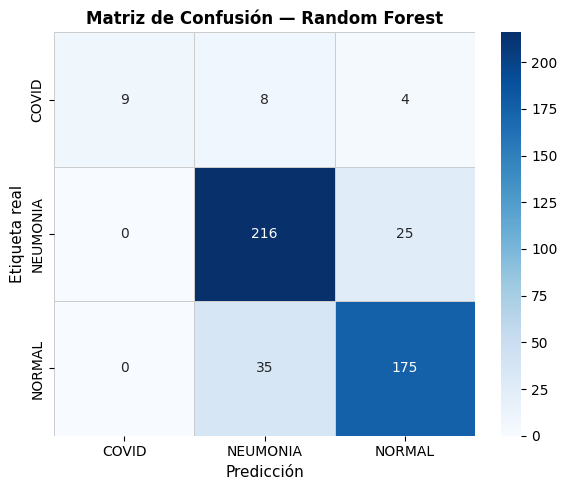

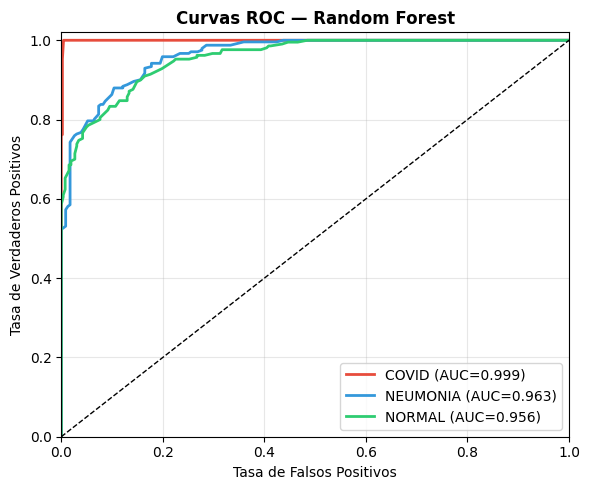

In [22]:
# ══════════════════════════════════════════════════════════
# Random Forest
# ══════════════════════════════════════════════════════════
_rf_path = MODELS_DIR / 'random_forest.pkl'
_t_start = time.time()
print(f"[Random Forest] Inicio: {time.strftime('%H:%M:%S')}")

if _rf_path.exists():
    rf_model = joblib.load(_rf_path)
    print("→ Modelo cargado.")
else:
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight='balanced',
        n_jobs=-1,
        random_state=SEED
    )
    rf_model.fit(X_train_pca, y_train)
    joblib.dump(rf_model, _rf_path)
    print("Modelo guardado.")

print(f"[Random Forest] Tiempo: {time.time()-_t_start:.1f}s")

y_pred_rf = rf_model.predict(X_test_pca)
y_prob_rf = rf_model.predict_proba(X_test_pca)
compute_metrics('Random Forest', y_test, y_pred_rf, y_prob_rf)
plot_confusion_matrix('Random Forest', y_test, y_pred_rf)
plot_roc_curves('Random Forest', y_test, y_prob_rf)


[Naive Bayes] Inicio: 11:15:40
Modelo guardado.
[Naive Bayes] Tiempo: 0.0s

  Naive Bayes
              precision    recall  f1-score   support

       COVID       0.47      0.67      0.55        21
    NEUMONIA       0.63      0.83      0.72       241
      NORMAL       0.70      0.41      0.52       210

    accuracy                           0.64       472
   macro avg       0.60      0.64      0.59       472
weighted avg       0.66      0.64      0.62       472

  Accuracy    : 0.6377
  Precision   : 0.6551
  Recall      : 0.6377
  F1_Score    : 0.6208
  AUC_ROC     : 0.8237


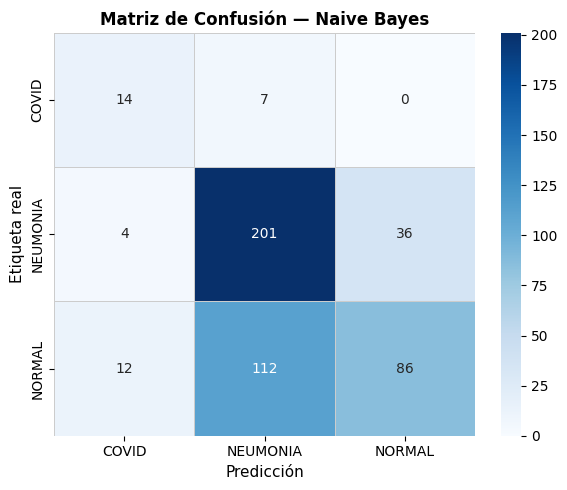

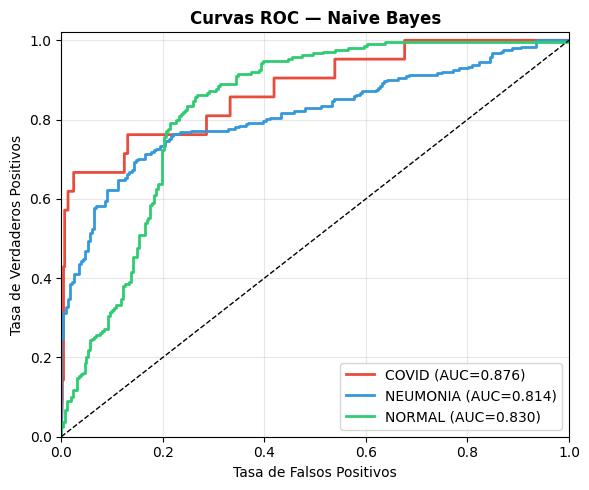

In [22]:
# ══════════════════════════════════════════════════════════
# Naive Bayes (GaussianNB)
# ══════════════════════════════════════════════════════════
_nb_path = MODELS_DIR / 'naive_bayes.pkl'
_t_start = time.time()
print(f"[Naive Bayes] Inicio: {time.strftime('%H:%M:%S')}")

if _nb_path.exists():
    nb_model = joblib.load(_nb_path)
    print("→ Modelo cargado.")
else:
    nb_model = GaussianNB()
    nb_model.fit(X_train_pca, y_train)
    joblib.dump(nb_model, _nb_path)
    print("Modelo guardado.")

print(f"[Naive Bayes] Tiempo: {time.time()-_t_start:.1f}s")

y_pred_nb = nb_model.predict(X_test_pca)
y_prob_nb = nb_model.predict_proba(X_test_pca)
compute_metrics('Naive Bayes', y_test, y_pred_nb, y_prob_nb)
plot_confusion_matrix('Naive Bayes', y_test, y_pred_nb)
plot_roc_curves('Naive Bayes', y_test, y_prob_nb)


---
## Bloque C — Perceptrón Multicapa (MLP)

MLP de sklearn con 3 capas ocultas **(512 → 256 → 128)**, activación ReLU,
regularización L2 (α=1e-4) y early stopping interno.


[MLP] Inicio: 11:15:53
Iteration 1, loss = 0.38440081
Validation score: 0.925234
Iteration 2, loss = 0.10919460
Validation score: 0.925234
Iteration 3, loss = 0.03921191
Validation score: 0.934579
Iteration 4, loss = 0.01220422
Validation score: 0.931464
Iteration 5, loss = 0.00497333
Validation score: 0.943925
Iteration 6, loss = 0.00231538
Validation score: 0.940810
Iteration 7, loss = 0.00170863
Validation score: 0.943925
Iteration 8, loss = 0.00144192
Validation score: 0.940810
Iteration 9, loss = 0.00127683
Validation score: 0.940810
Iteration 10, loss = 0.00116336
Validation score: 0.943925
Iteration 11, loss = 0.00107147
Validation score: 0.947040
Iteration 12, loss = 0.00100130
Validation score: 0.940810
Iteration 13, loss = 0.00094081
Validation score: 0.947040
Iteration 14, loss = 0.00089537
Validation score: 0.943925
Iteration 15, loss = 0.00087319
Validation score: 0.947040
Iteration 16, loss = 0.00084936
Validation score: 0.943925
Iteration 17, loss = 0.00083057
Validation

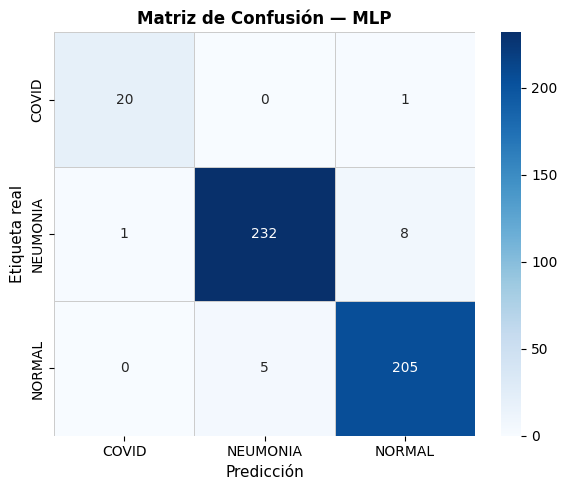

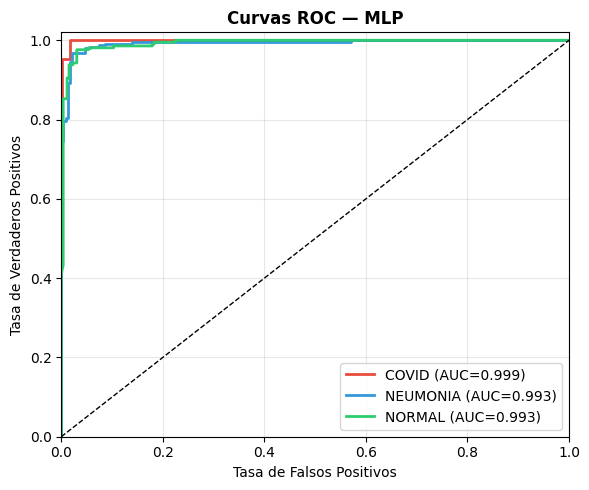

In [23]:
# ══════════════════════════════════════════════════════════
# MLP (sklearn)
# ══════════════════════════════════════════════════════════
_mlp_path = MODELS_DIR / 'mlp.pkl'
_t_start  = time.time()
print(f"[MLP] Inicio: {time.strftime('%H:%M:%S')}")

if _mlp_path.exists():
    mlp_model = joblib.load(_mlp_path)
    print("→ Modelo cargado.")
else:
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=64,
        learning_rate='adaptive',
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=12,
        random_state=SEED,
        verbose=True,
    )
    # Combinar train+val para MLP sklearn (usa early stopping interno)
    X_tv = np.vstack([X_train_pca, X_val_pca])
    y_tv = np.concatenate([y_train, y_val])
    mlp_model.fit(X_tv, y_tv)
    joblib.dump(mlp_model, _mlp_path)
    print("Modelo guardado.")

print(f"[MLP] Tiempo: {time.time()-_t_start:.1f}s")

y_pred_mlp = mlp_model.predict(X_test_pca)
y_prob_mlp = mlp_model.predict_proba(X_test_pca)
compute_metrics('MLP', y_test, y_pred_mlp, y_prob_mlp)
plot_confusion_matrix('MLP', y_test, y_pred_mlp)
plot_roc_curves('MLP', y_test, y_prob_mlp)


---
## Bloque D — ResNet50 (Transfer Learning)

**Fase 1 — Feature extraction (15 épocas):** base ResNet50 congelada, solo entrenan
las capas densas superiores.

**Fase 2 — Fine-tuning (hasta 20 épocas):** se descongelan las últimas 30 capas de
ResNet50 y se re-entrena con learning rate muy bajo (1e-5) para adaptar al dominio médico.


In [24]:
# ══════════════════════════════════════════════════════════
# ResNet50 – Transfer Learning + Fine-Tuning
# ══════════════════════════════════════════════════════════
_resnet_path  = MODELS_DIR / 'resnet50.keras'
_rhist_path   = MODELS_DIR / 'resnet_history.pkl'
_rtest_path   = MODELS_DIR / 'X_test_resnet.npy'
resnet_history = None

_t_start = time.time()
print(f"[ResNet50] Inicio: {time.strftime('%H:%M:%S')}")

if _resnet_path.exists():
    print("→ Cargando modelo guardado...")
    resnet_model = tf.keras.models.load_model(_resnet_path)
    if _rhist_path.exists():
        resnet_history = pickle.load(open(_rhist_path, 'rb'))
else:
    # Pre-procesar para ResNet (escala [-1,1] esperada por imagenet)
    X_train_r = resnet_preprocess(X_train * 255.0)
    X_val_r   = resnet_preprocess(X_val   * 255.0)
    X_test_r  = resnet_preprocess(X_test  * 255.0)
    np.save(_rtest_path, X_test_r)

    # ─── FASE 1: Feature extraction ───────────────────────
    _base = ResNet50(weights='imagenet', include_top=False,
                     input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    _base.trainable = False

    _inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS))
    _x   = _base(_inp, training=False)
    _x   = layers.GlobalAveragePooling2D()(_x)
    _x   = layers.Dense(256, activation='relu')(_x)
    _x   = layers.Dropout(0.40)(_x)
    _out = layers.Dense(len(CLASS_NAMES), activation='softmax')(_x)
    resnet_model = Model(_inp, _out, name='ResNet50_TL')

    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"  Fase 1 — parámetros entrenables: {resnet_model.count_params():,}")

    _h1 = resnet_model.fit(
        X_train_r, y_train, batch_size=BATCH_SIZE, epochs=15,
        validation_data=(X_val_r, y_val),
        class_weight=CLASS_WEIGHTS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        ],
        verbose=1,
    )

    # ─── FASE 2: Fine-tuning ──────────────────────────────
    _base.trainable = True
    for _layer in _base.layers[:-30]:
        _layer.trainable = False

    resnet_model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"  Fase 2 — capas entrenables (últimas 30): activo")

    _h2 = resnet_model.fit(
        X_train_r, y_train, batch_size=BATCH_SIZE, epochs=FT_EPOCHS,
        validation_data=(X_val_r, y_val),
        class_weight=CLASS_WEIGHTS,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
            ModelCheckpoint(str(_resnet_path), monitor='val_accuracy', save_best_only=True),
        ],
        verbose=1,
    )

    resnet_history = {
        k: _h1.history[k] + _h2.history[k]
        for k in _h1.history
    }
    pickle.dump(resnet_history, open(_rhist_path, 'wb'))
    print("Modelo guardado.")

print(f"[ResNet50] Tiempo: {time.time()-_t_start:.1f}s")


[ResNet50] Inicio: 11:16:17
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
  Fase 1 — parámetros entrenables: 24,113,027
Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8393 - loss: 0.4657 - val_accuracy: 0.9492 - val_loss: 0.1346 - learning_rate: 0.0010
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 65s 941ms/step - accuracy: 0.9117 - loss: 0.1823 - val_accuracy: 0.9407 - val_loss: 0.1783 - learning_rate: 0.0010
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9217 - loss: 0.1720 - val_accuracy: 0.9640 - val_loss: 0.1268 - learning_rate: 0.0010
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9299 - loss: 0.1379 - val_accuracy: 0.9576 - val_loss: 0.1507 - learning_rate: 0.0010
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 873ms/step - accuracy: 0.9340 - loss: 0.1346 - val_accuracy: 0.9767 - val_loss: 0.0893 - learning_rate: 0.0010
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 875ms/step - accuracy: 0.9477 - loss: 0.1026 - val_accuracy: 0.9767 - val_lo


  ResNet50
              precision    recall  f1-score   support

       COVID       0.91      0.95      0.93        21
    NEUMONIA       1.00      0.97      0.98       241
      NORMAL       0.96      0.99      0.97       210

    accuracy                           0.97       472
   macro avg       0.95      0.97      0.96       472
weighted avg       0.98      0.97      0.97       472

  Accuracy    : 0.9746
  Precision   : 0.9752
  Recall      : 0.9746
  F1_Score    : 0.9747
  AUC_ROC     : 0.9973


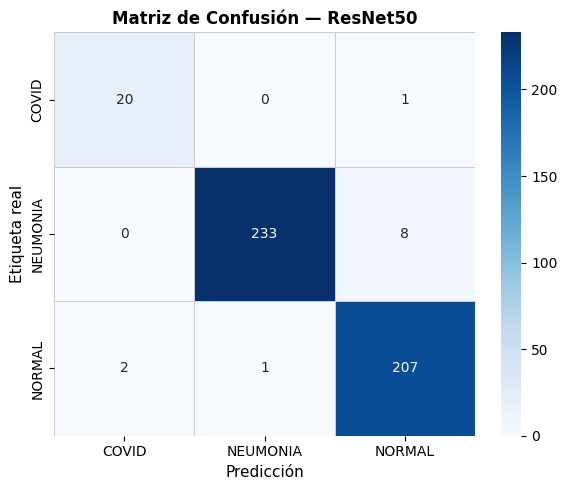

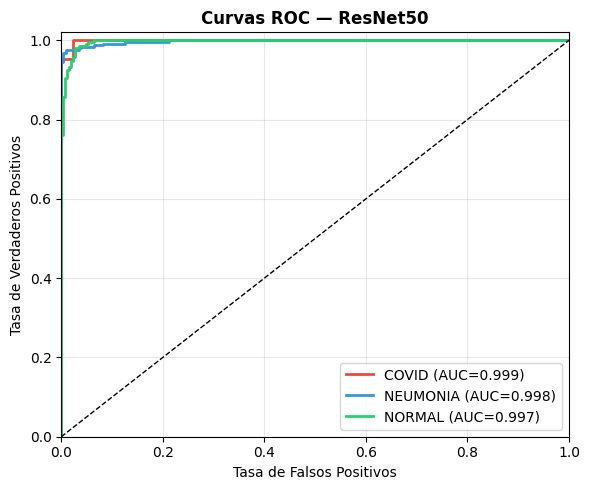

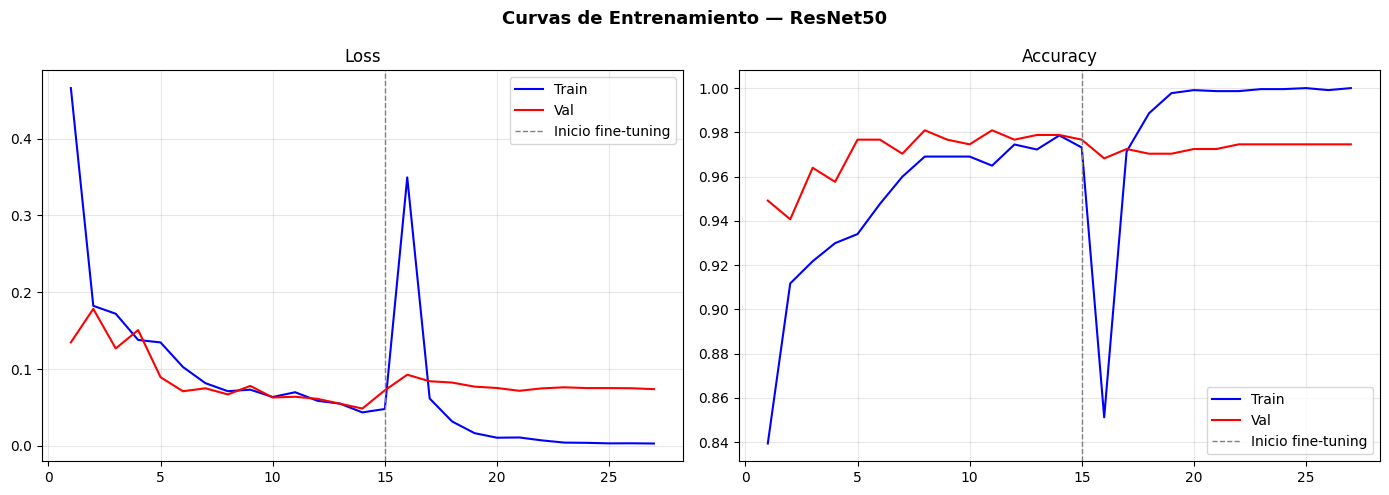

In [25]:
# ══════════════════════════════════════════════════════════
# Evaluación ResNet50
# ══════════════════════════════════════════════════════════
_X_test_r = (np.load(_rtest_path) if _rtest_path.exists()
             else resnet_preprocess(X_test * 255.0))

y_prob_resnet = resnet_model.predict(_X_test_r, verbose=0)
y_pred_resnet = np.argmax(y_prob_resnet, axis=1)

compute_metrics('ResNet50', y_test, y_pred_resnet, y_prob_resnet)
plot_confusion_matrix('ResNet50', y_test, y_pred_resnet)
plot_roc_curves('ResNet50', y_test, y_prob_resnet)

# Curvas de entrenamiento
if resnet_history:
    _ep = range(1, len(resnet_history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Curvas de Entrenamiento — ResNet50', fontsize=13, fontweight='bold')
    axes[0].plot(_ep, resnet_history['loss'],     'b-', label='Train')
    axes[0].plot(_ep, resnet_history['val_loss'], 'r-', label='Val')
    axes[0].axvline(15, color='gray', ls='--', lw=1, label='Inicio fine-tuning')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(_ep, resnet_history['accuracy'],     'b-', label='Train')
    axes[1].plot(_ep, resnet_history['val_accuracy'], 'r-', label='Val')
    axes[1].axvline(15, color='gray', ls='--', lw=1, label='Inicio fine-tuning')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'resnet_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


---
## Bloque E — YOLOv8 para Clasificación

Se usa **YOLOv8n-cls** (nano, ~2 M parámetros) en modo clasificación vía Ultralytics.
Primero se construye la estructura de directorios requerida por YOLO copiando las imágenes
originales con el mismo split estratificado que los demás modelos.

```
yolo_dataset/
  train/ {COVID, NEUMONIA, NORMAL}/
  val/   {COVID, NEUMONIA, NORMAL}/
  test/  {COVID, NEUMONIA, NORMAL}/
```


In [26]:
# ══════════════════════════════════════════════════════════
# Construir estructura de directorios para YOLO
# ══════════════════════════════════════════════════════════
print("Preparando dataset YOLO...")
_t0 = time.time()

# Reconstruir lista de archivos válidos en el mismo orden que X_all
_all_paths  = []
_all_labels = []
for _lbl, (cls, files) in enumerate(all_files.items()):
    for f in files:
        try:
            Image.open(f)   # verificar que es abrible
            _all_paths.append(f)
            _all_labels.append(_lbl)
        except:
            pass

_idx = np.arange(len(_all_paths))
_idx_tv, _idx_test = train_test_split(
    _idx, test_size=TEST_SPLIT,
    stratify=_all_labels, random_state=SEED
)
_idx_train, _idx_val = train_test_split(
    _idx_tv, test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=[_all_labels[i] for i in _idx_tv], random_state=SEED
)

def _copy_to_yolo(indices, split_name):
    for i in indices:
        src     = _all_paths[i]
        cls_n   = CLASS_NAMES[_all_labels[i]]
        dst_dir = YOLO_DIR / split_name / cls_n
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst     = dst_dir / src.name
        if not dst.exists():
            shutil.copy2(src, dst)

if not (YOLO_DIR / 'train').exists():
    _copy_to_yolo(_idx_train, 'train')
    _copy_to_yolo(_idx_val,   'val')
    _copy_to_yolo(_idx_test,  'test')
    print("  Dataset YOLO creado.")
else:
    print("  Dataset YOLO ya existía.")

print("\n  Conteo:")
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        n = len(list((YOLO_DIR / split / cls).glob('*')))
        print(f"    {split}/{cls}: {n}")

print(f"\nTiempo: {time.time()-_t0:.1f}s")


Preparando dataset YOLO...
  Dataset YOLO creado.

  Conteo:
    train/COVID: 96
    train/NEUMONIA: 1122
    train/NORMAL: 979
    val/COVID: 21
    val/NEUMONIA: 241
    val/NORMAL: 210
    test/COVID: 21
    test/NEUMONIA: 241
    test/NORMAL: 210

Tiempo: 4.5s


In [27]:
# ══════════════════════════════════════════════════════════
# Entrenamiento YOLOv8-cls
# ══════════════════════════════════════════════════════════
_yolo_run_dir = MODELS_DIR / 'yolo_run'
_t_start      = time.time()
print(f"[YOLO] Inicio: {time.strftime('%H:%M:%S')}")

# Buscar best.pt si ya existe
_best_pts = list(_yolo_run_dir.rglob('best.pt')) if _yolo_run_dir.exists() else []

if _best_pts:
    print("→ Modelo YOLO guardado encontrado.")
    yolo_model = YOLOModel(str(_best_pts[0]))
else:
    yolo_model = YOLOModel('yolov8n-cls.pt')
    yolo_model.train(
        data=str(YOLO_DIR),
        epochs=30,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        project=str(MODELS_DIR),
        name='yolo_run',
        patience=8,
        seed=SEED,
        verbose=False,
        plots=True,
    )
    print("YOLO entrenado.")

print(f"[YOLO] Tiempo: {time.time()-_t_start:.1f}s")


[YOLO] Inicio: 11:50:41
New https://pypi.org/project/ultralytics/8.4.36 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.11.9 torch-2.11.0+cu130 CPU (Intel Core i7-14700T)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/uplaph/Documentos/UPMH/Proyecto final algoritmos/yolo_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, 

YOLO class names: {0: 'COVID', 1: 'NEUMONIA', 2: 'NORMAL'}

  YOLOv8
              precision    recall  f1-score   support

       COVID       1.00      0.95      0.98        21
    NEUMONIA       0.99      0.97      0.98       241
      NORMAL       0.96      0.99      0.97       210

    accuracy                           0.98       472
   macro avg       0.98      0.97      0.98       472
weighted avg       0.98      0.98      0.98       472

  Accuracy    : 0.9767
  Precision   : 0.9772
  Recall      : 0.9767
  F1_Score    : 0.9767
  AUC_ROC     : 0.9980


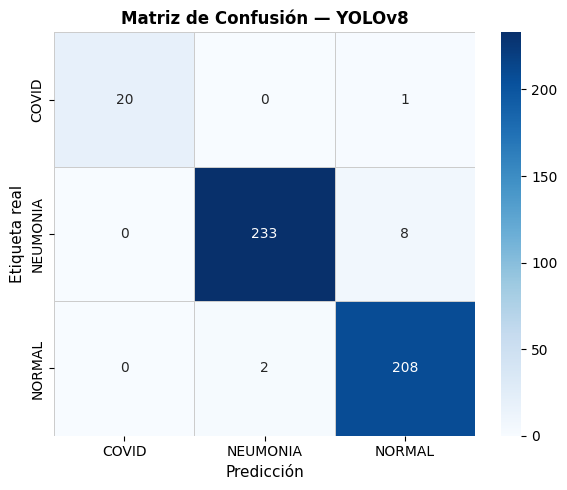

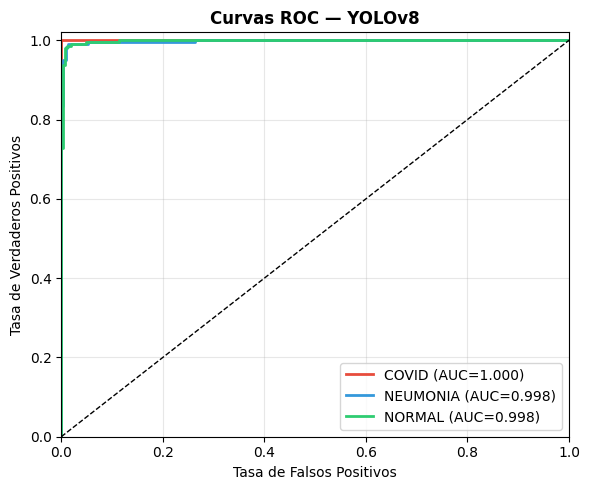

In [28]:
# ══════════════════════════════════════════════════════════
# Evaluación YOLO
# ══════════════════════════════════════════════════════════
if yolo_model is not None:
    _yolo_preds  = []
    _yolo_probs  = []
    _yolo_labels = []

    for _cls_idx, cls_name in enumerate(CLASS_NAMES):
        _cls_dir = YOLO_DIR / 'test' / cls_name
        _imgs    = [str(p) for p in _cls_dir.iterdir()
                    if p.suffix.lower() in EXTENSIONS]
        _BATCH   = 32
        for _i in range(0, len(_imgs), _BATCH):
            _batch_imgs = _imgs[_i:_i+_BATCH]
            _preds = yolo_model.predict(_batch_imgs, verbose=False)
            for _p in _preds:
                _probs_arr = _p.probs.data.cpu().numpy()
                _yolo_probs.append(_probs_arr)
                _yolo_preds.append(int(np.argmax(_probs_arr)))
                _yolo_labels.append(_cls_idx)

    _yolo_preds  = np.array(_yolo_preds)
    _yolo_probs  = np.array(_yolo_probs)
    _yolo_labels = np.array(_yolo_labels)

    print(f"YOLO class names: {yolo_model.names}")

    compute_metrics('YOLOv8', _yolo_labels, _yolo_preds, _yolo_probs)
    plot_confusion_matrix('YOLOv8', _yolo_labels, _yolo_preds)
    plot_roc_curves('YOLOv8', _yolo_labels, _yolo_probs)
else:
    print("YOLO no disponible — se inserta NaN en tabla comparativa.")
    all_results['YOLOv8'] = {k: float('nan')
                              for k in ['Accuracy','Precision','Recall','F1_Score','AUC_ROC']}


---
## Bloque F — Tabla Comparativa Final


In [29]:
# ══════════════════════════════════════════════════════════
# DataFrame comparativo
# ══════════════════════════════════════════════════════════
_cols = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC']

results_df = (
    pd.DataFrame(all_results).T
      .reindex(columns=_cols)
      .sort_values('F1_Score', ascending=False)
      .round(4)
)
results_df.index.name = 'Modelo'

print("\n" + "=" * 70)
print("   TABLA COMPARATIVA — CLASIFICACIÓN DE RADIOGRAFÍAS RESPIRATORIAS")
print("=" * 70)
print(results_df.to_string())

_csv = RESULTS_DIR / 'comparativa_modelos.csv'
results_df.to_csv(_csv)
print(f"\nGuardado: {_csv}")



   TABLA COMPARATIVA — CLASIFICACIÓN DE RADIOGRAFÍAS RESPIRATORIAS
             Accuracy  Precision  Recall  F1_Score  AUC_ROC
Modelo                                                     
YOLOv8         0.9767     0.9772  0.9767    0.9767   0.9980
ResNet50       0.9746     0.9752  0.9746    0.9747   0.9973
MLP            0.9682     0.9684  0.9682    0.9682   0.9930
SVM            0.9640     0.9643  0.9640    0.9640   0.9955
KNN            0.9301     0.9302  0.9301    0.9301   0.9796
Naive Bayes    0.6377     0.6551  0.6377    0.6208   0.8237
CNN Propia     0.0445     0.0020  0.0445    0.0038   0.4911

Guardado: /home/uplaph/Documentos/UPMH/Proyecto final algoritmos/results/comparativa_modelos.csv


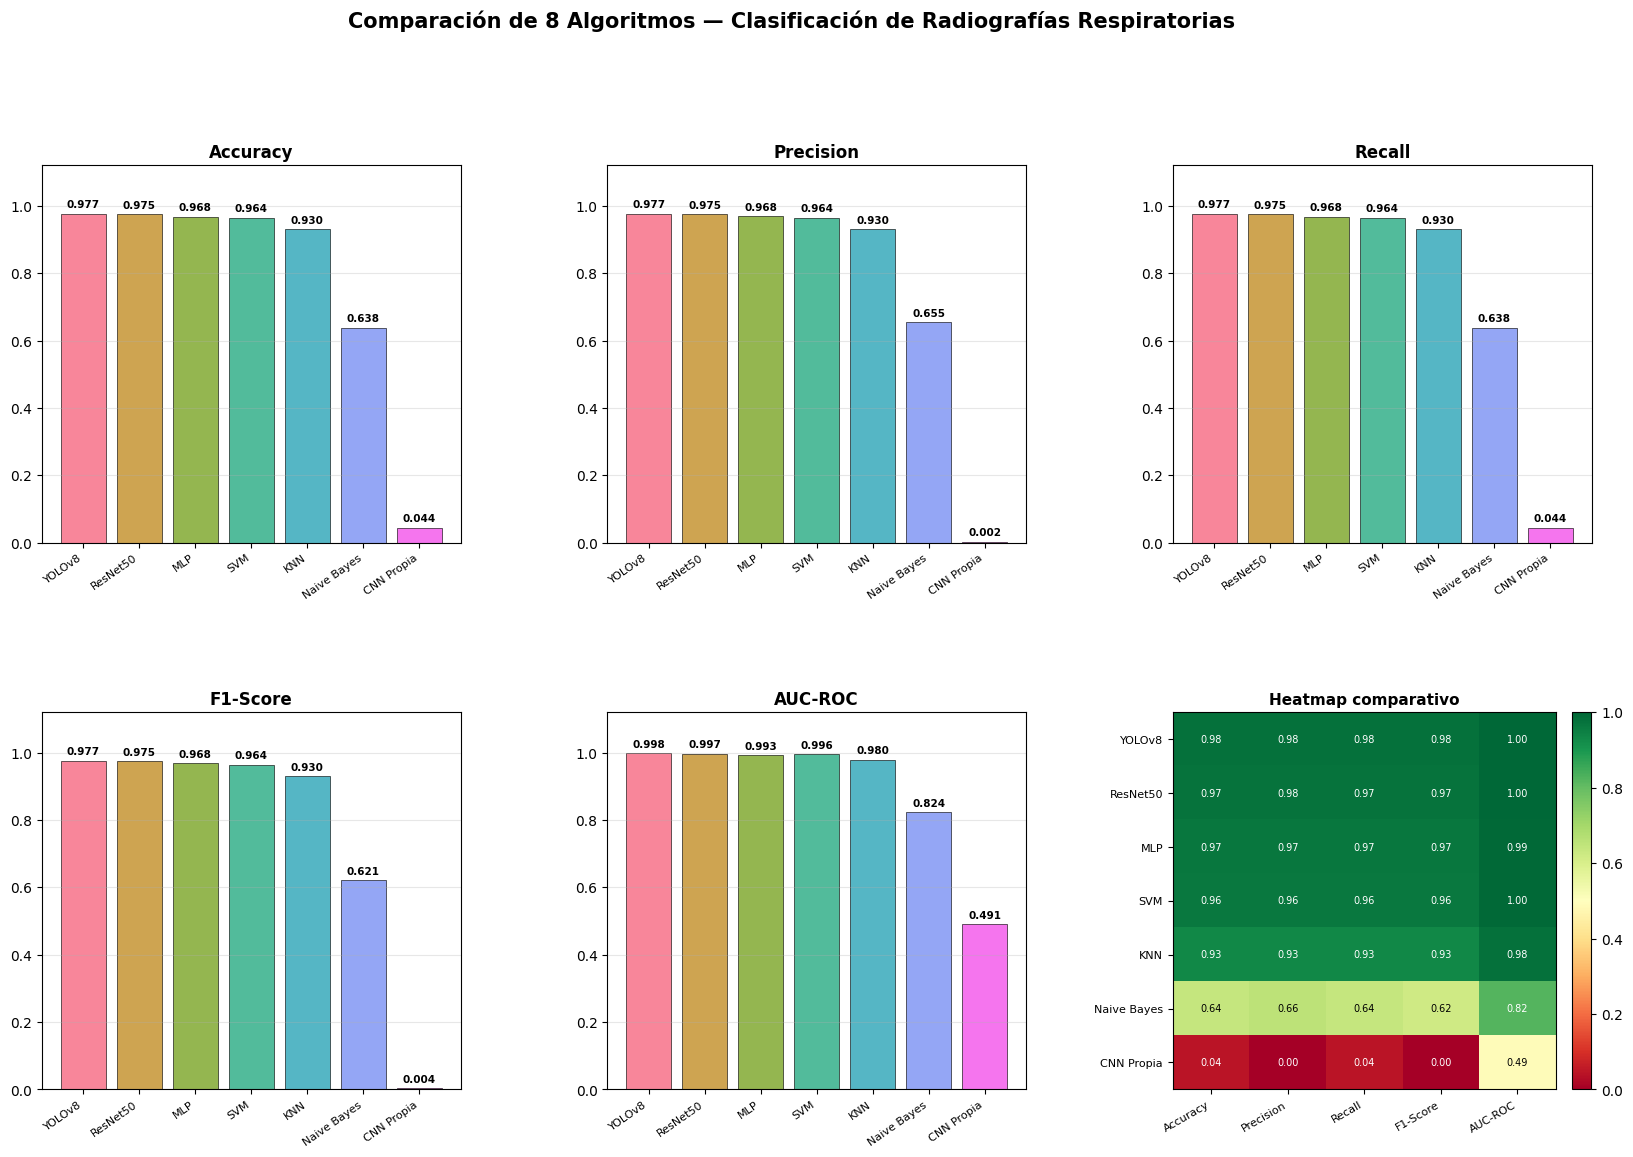

In [30]:
# ══════════════════════════════════════════════════════════
# Visualización comparativa
# ══════════════════════════════════════════════════════════
_metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC_ROC']
_models       = results_df.index.tolist()
_palette      = sns.color_palette('husl', len(_models))

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    'Comparación de 8 Algoritmos — Clasificación de Radiografías Respiratorias',
    fontsize=15, fontweight='bold', y=1.01
)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

for _idx, metric in enumerate(_metrics_plot):
    _r, _c = divmod(_idx, 3)
    ax = fig.add_subplot(gs[_r, _c])
    _vals = results_df[metric].values.astype(float)
    _bars = ax.bar(_models, _vals, color=_palette, alpha=0.85,
                   edgecolor='black', linewidth=0.5)
    ax.set_ylim(0, 1.12)
    ax.set_title(metric.replace('_', '-'), fontsize=12, fontweight='bold')
    ax.set_xticklabels(_models, rotation=35, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(_bars, _vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Panel 6: Heatmap
ax_h = fig.add_subplot(gs[1, 2])
_hdata = results_df[_metrics_plot].fillna(0)
_im    = ax_h.imshow(_hdata.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax_h.set_xticks(range(len(_metrics_plot)))
ax_h.set_xticklabels([m.replace('_', '-') for m in _metrics_plot],
                      rotation=30, ha='right', fontsize=8)
ax_h.set_yticks(range(len(_models)))
ax_h.set_yticklabels(_models, fontsize=8)
ax_h.set_title('Heatmap comparativo', fontsize=11, fontweight='bold')
plt.colorbar(_im, ax=ax_h, fraction=0.046, pad=0.04)
for i in range(len(_models)):
    for j in range(len(_metrics_plot)):
        v = _hdata.values[i, j]
        ax_h.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                  color='black' if 0.25 < v < 0.8 else 'white')

plt.savefig(RESULTS_DIR / 'comparativa_final.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════
# Tabla estilizada (se renderiza en Jupyter)
# ══════════════════════════════════════════════════════════
def _highlight_best(s):
    _is_best = s == s.max()
    return ['background-color:#27AE60; color:white; font-weight:bold'
            if v else '' for v in _is_best]

def _highlight_worst(s):
    _is_worst = s == s.min()
    return ['background-color:#E74C3C; color:white'
            if v else '' for v in _is_worst]

(results_df.style
    .apply(_highlight_best,  axis=0)
    .apply(_highlight_worst, axis=0)
    .format('{:.4f}')
    .set_caption('Resultados comparativos — verde: mejor | rojo: peor por métrica')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','14px'),('font-weight','bold'),('margin-bottom','10px')]},
        {'selector': 'th',
         'props': [('background-color','#2C3E50'),('color','white'),
                   ('font-size','11px'),('text-align','center'),('padding','8px')]},
        {'selector': 'td',
         'props': [('font-size','11px'),('text-align','center'),('padding','6px')]},
    ])
)


,Accuracy,Precision,Recall,F1_Score,AUC_ROC
Modelo,,,,,
YOLOv8,0.9767,0.9772,0.9767,0.9767,0.9980
ResNet50,0.9746,0.9752,0.9746,0.9747,0.9973
MLP,0.9682,0.9684,0.9682,0.9682,0.9930
SVM,0.9640,0.9643,0.9640,0.9640,0.9955
KNN,0.9301,0.9302,0.9301,0.9301,0.9796
Naive Bayes,0.6377,0.6551,0.6377,0.6208,0.8237
CNN Propia,0.0445,0.0020,0.0445,0.0038,0.4911


---
## Conclusiones

Este pipeline evaluó **8 algoritmos** sobre un dataset de **3,142 radiografías** de tórax
con desbalance significativo (COVID: 138, Neumonía: 1,605, Normal: 1,399).

### Hallazgos del dataset
- Imágenes de dimensiones muy variables (800–2,500 px) y modos mixtos (L / RGB / RGBA)
- Estandarización a 224×224 RGB fue necesaria para compatibilidad uniforme
- Desbalance de ~11:1 entre COVID y Neumonía → mitigado con `class_weight='balanced'`

### Archivos generados
Todos los modelos y gráficas se encuentran en la carpeta `results/` y `models/`.

| Archivo | Contenido |
|---------|-----------|
| `comparativa_modelos.csv` | Tabla con todas las métricas |
| `comparativa_final.png` | Visualización comparativa completa |
| `cm_*.png` | Matrices de confusión por modelo |
| `roc_*.png` | Curvas ROC por modelo |
| `cnn_training_curves.png` | Curvas de loss/accuracy CNN |
| `resnet_training_curves.png` | Curvas de loss/accuracy ResNet50 |

### Para el artículo científico
Los resultados del **Bloque A (CNN Propia)** son el núcleo del artículo de Análisis de Algoritmos.
Los bloques B–E sirven para el proyecto de Aprendizaje Automático Supervisado.
